In [22]:
import os
import glob
import math
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from matplotlib.ticker import MultipleLocator
import dendropy
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import matplotlib as mpl
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [23]:
# Plot precision recall curves for different migration windows
main_dir="/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/migration_windows_sim_data_mig1e-4_11_20_25"
pr_file=f"{main_dir}/precision_recall_curve/precision_recall_vars.pkl"
f1_file=f"{main_dir}/precision_recall_curve/metrics.csv"

with open(pr_file, "rb") as f:
        (
            pathfinder_precisions,
            pathfinder_recalls,
            machina_precisions,
            machina_recalls,
            random_precisions,
            random_recalls,
            consensus_precisions,
            consensus_recalls,
            parsimony_precisions,
            parsimony_recalls,
            metient_df,
            mach2_df,
            beam_df,
        ) = pickle.load(f)

f1 = pd.read_csv(f1_file)
f1['migration_window'] = ["_".join(sim_name.split('_')[0:2]) for sim_name in f1['sim']]
beam_df['migration_window'] = ["_".join(sim_name.split('_')[0:2]) for sim_name in beam_df['sim']]
metient_df['migration_window'] = ["_".join(sim_name.split('_')[0:2]) for sim_name in metient_df['sim']]
mach2_df['migration_window'] = ["_".join(sim_name.split('_')[0:2]) for sim_name in mach2_df['sim']]

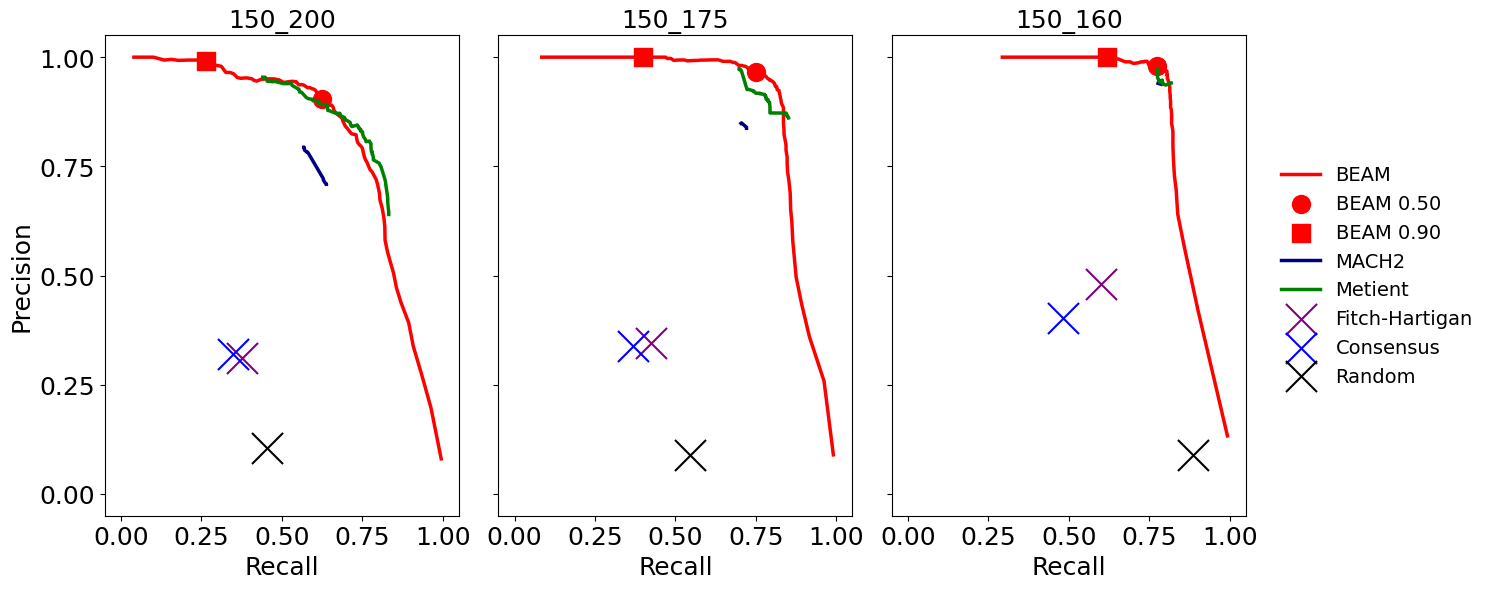

In [24]:
# Create figure and axes
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
fs = 24
size = 500
textsize = 18

windows = ["150_200", "150_175", "150_160"]


# Define color palette for main comparison plot
method_colors = {
    "BEAM": "red",
    "Random": "black",
    "Fitch-Hartigan": "purple",
    "PathFinder": "orange",
    "MACHINA": "gold",
    "Metient": "green",
    "Consensus": "blue",
    "MACH2": "navy",
}

for i, (ax, window) in enumerate(zip(axes, windows)):
    f1_sub = f1[f1['migration_window'] == window]
    beam_df_sub = beam_df[beam_df['migration_window'] == window]
    metient_df_sub = metient_df[metient_df['migration_window'] == window]
    mach2_df_sub = mach2_df[mach2_df['migration_window'] == window]
    
    avg_beam_df = beam_df_sub.groupby("Threshold")[["precision", "recall"]].mean().reset_index()
    avg_metient_df = metient_df_sub.groupby("Threshold")[["precision", "recall"]].mean().reset_index()
    avg_mach2_df = mach2_df_sub.groupby("Threshold")[["precision", "recall"]].mean().reset_index()

    # BEAM
    ax.plot(avg_beam_df["recall"], avg_beam_df["precision"], color=method_colors["BEAM"], label="BEAM", lw=2.5)
    for thresh, marker in zip([0.50, 0.90], ["o", "s"]):
        df_thresh = avg_beam_df[avg_beam_df["Threshold"] == thresh]
        if not df_thresh.empty:
            ax.scatter(df_thresh["recall"], df_thresh["precision"], facecolors=method_colors["BEAM"], edgecolors=method_colors["BEAM"], s=size / 3, marker=marker, label=f"BEAM {thresh:.2f}")
            
    # MACH2
    ax.plot(avg_mach2_df["recall"], avg_mach2_df["precision"], color=method_colors["MACH2"], label="MACH2", lw=2.5)

    # Metient
    ax.plot(avg_metient_df["recall"], avg_metient_df["precision"], color=method_colors["Metient"], label="Metient", lw=2.5)

    # Single-point methods
    single_point_methods = [
        ("Fitch-Hartigan", f1_sub["Fitch-Hartigan_recall"].mean(), f1_sub["Fitch-Hartigan_precision"].mean()),
        ("Consensus", f1_sub["Consensus_recall"].mean(), f1_sub["Consensus_precision"].mean()),
        ("Random", f1_sub["Random_recall"].mean(), f1_sub["Random_precision"].mean())
    ]

    for name, recall, precision in single_point_methods:
        ax.scatter(recall, precision, color=method_colors[name], s=size, marker="x", label=name)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Recall", fontsize=textsize)
    if i == 0:
        ax.set_ylabel("Precision", fontsize=textsize)
    ax.set_title(window, fontsize=textsize)
    ax.tick_params(axis="both", which="major", labelsize=textsize)
    
    ax.xaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))

    if i == len(windows) - 1:
        ax.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=14, edgecolor="none")

plt.tight_layout()
# plt.savefig(f"")
plt.show()
plt.close()


In [25]:
# Migration timing plot for beam
migration_files = glob.glob(main_dir + "/beam_gtr/*/metastasis_timing.pkl")

sim_midpoints = {}
sim_migration_probs = {}

for sim in migration_files:
    sim_name = os.path.basename(os.path.dirname(sim))
    sim_midpoints[sim_name] = []
    sim_migration_probs[sim_name] = [0]*250
    sim_migrations_dict = pickle.load(open(sim, "rb"))
    for posterior_sample, migrations_dict in sim_migrations_dict.items():
        for migration_event, (start, stop) in migrations_dict.items():
            midpoint = (start + stop) / 2
            sim_midpoints[sim_name].append(midpoint)
            for t in range(int(start), int(stop) + 1):
                sim_migration_probs[sim_name][t-1] += 1
    # Normalize migration probabilities to get a probability distribution
    total_count = sum(sim_migration_probs[sim_name])
    for t in range(0, 250):
        sim_migration_probs[sim_name][t] /= total_count


In [28]:
def get_tissue(node):
    if node.label:
        return node.label.split("_")[-1]
    else:
        return node.taxon.label.split("_")[-1]

methods = ["parsimony", "consensus", "random"]

sim_midpoints_others = {}
sim_migration_probs_others = {}

for method in methods:
    
    # Migration timing plot for fitch-hartigan parsimony, consensus, and random tissue labeling on branch length resolved trees
    tree_files = glob.glob(main_dir + f"/random_consensus_parsimony_tissue_inference/*/{method}_tissues_with_branch_lengths.nwk")
    
    sim_midpoints_others[method] = {}
    sim_migration_probs_others[method] = {}
    
    for tree_file in tree_files:
        sim_name = os.path.basename(os.path.dirname(tree_file))
        sim_midpoints_others[method][sim_name] = []
        sim_migration_probs_others[method][sim_name] = [0]*250
        
        tree = dendropy.Tree.get(path=tree_file, schema="newick", preserve_underscores=True)
        
        heights = [leaf.distance_from_root() for leaf in tree.leaf_node_iter()]
        tree_height = max(heights)
        assert abs(tree_height - 250) < 0.5, f"Tree height not ~250, it is {tree_height}."

        for node in tree.preorder_node_iter():
            if node is tree.seed_node:
                parent_tissue = "P"
                parent_time = 0
            else:
                parent_node = node.parent_node
                parent_tissue = get_tissue(parent_node)
                parent_time = parent_node.distance_from_root()
            
            child_tissue = get_tissue(node)
                
            # migration event if tissues differ
            if child_tissue != parent_tissue:
                child_time = node.distance_from_root()
                midpoint = (parent_time + child_time) / 2
                sim_midpoints_others[method][sim_name].append(midpoint)
                for t in range(int(parent_time), int(child_time) + 1):
                    sim_migration_probs_others[method][sim_name][t-1] += 1
        # Normalize migration probabilities
        total_count = sum(sim_migration_probs_others[method][sim_name])
        for t in range(0, 250):
            sim_migration_probs_others[method][sim_name][t] /= total_count


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
fs = 18
bins = np.linspace(0, 250, 251)

legend_handles = [
    Line2D([0], [0], color="lightblue", lw=2, label="LAML/Fitch-Hartigan midpoints"),
    Line2D([0], [0], color="navy", lw=2, label="LAML/Fitch-Hartigan probabilities"),
    Line2D([0], [0], color="grey", lw=2, label="BEAM midpoints"),
    Line2D([0], [0], color="black", lw=2, label="BEAM probabilities"),
    Patch(facecolor="red", alpha=0.2, label="Simulated window"),
]

windows = ["150_200", "150_175", "150_160"]


for col_idx, window in enumerate(windows):
    ax = axes[col_idx]
    
    # Plot fitch-hartigan parsimony
    method = "parsimony"
    fitch_sims = {s: mids for s, mids in sim_midpoints_others[method].items() if s.startswith(window)}
    N = len(fitch_sims)
    fitch_avg_prob = np.zeros(250)
    fitch_midpoints = []
    for sim_name, mids in fitch_sims.items():
        fitch_midpoints.extend(mids)
        fitch_avg_prob += np.array(sim_migration_probs_others[method][sim_name]) / N
    if len(fitch_midpoints) > 1:
        kde = gaussian_kde(fitch_midpoints)
        xs = np.linspace(0, 250, 500)
        ax.plot(xs, kde(xs), color="lightblue", lw=2)
    ax.plot((bins[:-1] + bins[1:]) / 2, fitch_avg_prob, color="navy", lw=2)
    
    # Plot BEAM
    sims = {s: mids for s, mids in sim_midpoints.items() if s.startswith(window)}
    N = len(sims)
    avg_prob = np.zeros(250)
    midpoints = []
    for sim_name, mids in sims.items():
            midpoints.extend(mids)
            avg_prob += np.array(sim_migration_probs[sim_name]) / N
    if len(midpoints) > 1:
        kde = gaussian_kde(midpoints)
        xs = np.linspace(0, 250)
        ax.plot(xs, kde(xs), color="grey", lw=2)
    ax.plot((bins[:-1] + bins[1:]) / 2, avg_prob, color="black", lw=2)

    # Simulated window overlay
    window_start, window_end = map(int, window.split("_"))
    ax.axvspan(window_start, window_end, color="red", alpha=0.2)

    # Labels
    ax.tick_params(axis='both', labelsize=fs-4)
    ax.set_xlim(0, 250)
    ax.set_xticks(np.arange(0, 251, 50))


    ax.set_title(window, fontsize=fs)

fig.supxlabel("Simulation time", fontsize=fs)
fig.supylabel("Migration density", fontsize=fs)

plt.legend(handles=legend_handles,
           fontsize=fs-6,
           bbox_to_anchor=(1.05, 1),
           loc="upper left",
           edgecolor="none")

plt.tight_layout()
plt.savefig(f"{main_dir}/timing_line.pdf")
# plt.show()
plt.close()


In [31]:
def posterior_mass_in_window(prob_array, start, stop):
    # start and stop inclusive
    return sum(prob_array[start-1 : stop])   # because t-1 indexing

def midpoint_pmass(midpoints, start, stop):
    return np.mean([(start <= m <= stop) for m in midpoints])

# Calculate for BEAM
all_pmass_150_200 = []
all_pmass_150_175 = []
all_pmass_150_160 = []

all_mid_pmass_150_200 = []
all_mid_pmass_150_175 = []
all_mid_pmass_150_160 = []

for sim in sim_migration_probs:
    pmass_150_200 = posterior_mass_in_window(sim_migration_probs[sim], 150, 200)
    pmass_150_175 = posterior_mass_in_window(sim_migration_probs[sim], 150, 175)
    pmass_150_160 = posterior_mass_in_window(sim_migration_probs[sim], 150, 160)
    all_pmass_150_200.append(pmass_150_200)
    all_pmass_150_175.append(pmass_150_175)
    all_pmass_150_160.append(pmass_150_160)
    
    mid_pmass_150_200 = midpoint_pmass(sim_midpoints[sim], 150, 200)
    mid_pmass_150_175 = midpoint_pmass(sim_midpoints[sim], 150, 175)
    mid_pmass_150_160 = midpoint_pmass(sim_midpoints[sim], 150, 160)
    all_mid_pmass_150_200.append(mid_pmass_150_200)
    all_mid_pmass_150_175.append(mid_pmass_150_175)
    all_mid_pmass_150_160.append(mid_pmass_150_160)



# Calculate for other methods
all_pmass_150_200_others = {method: [] for method in methods}
all_pmass_150_175_others = {method: [] for method in methods}
all_pmass_150_160_others = {method: [] for method in methods}

all_mid_pmass_150_200_others = {method: [] for method in methods}
all_mid_pmass_150_175_others = {method: [] for method in methods}
all_mid_pmass_150_160_others = {method: [] for method in methods}

for method in methods:
    for sim in sim_migration_probs_others[method]:
        pmass_150_200 = posterior_mass_in_window(sim_migration_probs_others[method][sim], 150, 200)
        pmass_150_175 = posterior_mass_in_window(sim_migration_probs_others[method][sim], 150, 175)
        pmass_150_160 = posterior_mass_in_window(sim_migration_probs_others[method][sim], 150, 160)
        all_pmass_150_200_others[method].append(pmass_150_200)
        all_pmass_150_175_others[method].append(pmass_150_175)
        all_pmass_150_160_others[method].append(pmass_150_160)
        
        mid_pmass_150_200 = midpoint_pmass(sim_midpoints_others[method][sim], 150, 200)
        mid_pmass_150_175 = midpoint_pmass(sim_midpoints_others[method][sim], 150, 175)
        mid_pmass_150_160 = midpoint_pmass(sim_midpoints_others[method][sim], 150, 160)
        all_mid_pmass_150_200_others[method].append(mid_pmass_150_200)
        all_mid_pmass_150_175_others[method].append(mid_pmass_150_175)
        all_mid_pmass_150_160_others[method].append(mid_pmass_150_160)


In [32]:
rows = []

# Add BEAM entries
for v in all_pmass_150_200:
    rows.append({"method": "BEAM", "window": "150-200", "pmass": v, "ptype": "Probabilities"})
for v in all_pmass_150_175:
    rows.append({"method": "BEAM", "window": "150-175", "pmass": v, "ptype": "Probabilities"})
for v in all_pmass_150_160:
    rows.append({"method": "BEAM", "window": "150-160", "pmass": v, "ptype": "Probabilities"})

for v in all_mid_pmass_150_200:
    rows.append({"method": "BEAM", "window": "150-200", "pmass": v, "ptype": "Midpoints"})
for v in all_mid_pmass_150_175:
    rows.append({"method": "BEAM", "window": "150-175", "pmass": v, "ptype": "Midpoints"})
for v in all_mid_pmass_150_160:
    rows.append({"method": "BEAM", "window": "150-160", "pmass": v, "ptype": "Midpoints"})

# Add OTHER methods
for method in methods[:1]:
    # density version
    for v in all_pmass_150_200_others[method]:
        rows.append({"method": method, "window": "150-200", "pmass": v, "ptype": "Probabilities"})
    for v in all_pmass_150_175_others[method]:
        rows.append({"method": method, "window": "150-175", "pmass": v, "ptype": "Probabilities"})
    for v in all_pmass_150_160_others[method]:
        rows.append({"method": method, "window": "150-160", "pmass": v, "ptype": "Probabilities"})

    # midpoint version
    for v in all_mid_pmass_150_200_others[method]:
        rows.append({"method": method, "window": "150-200", "pmass": v, "ptype": "Midpoints"})
    for v in all_mid_pmass_150_175_others[method]:
        rows.append({"method": method, "window": "150-175", "pmass": v, "ptype": "Midpoints"})
    for v in all_mid_pmass_150_160_others[method]:
        rows.append({"method": method, "window": "150-160", "pmass": v, "ptype": "Midpoints"})


df = pd.DataFrame(rows)
df


,method,window,pmass,ptype
0,BEAM,150-200,0.232848,Probabilities
1,BEAM,150-200,0.207091,Probabilities
2,BEAM,150-200,0.165053,Probabilities
3,BEAM,150-200,0.227621,Probabilities
4,BEAM,150-200,0.184022,Probabilities
...,...,...,...,...
1795,parsimony,150-160,0.052632,Midpoints
1796,parsimony,150-160,0.100000,Midpoints
1797,parsimony,150-160,0.000000,Midpoints
1798,parsimony,150-160,0.000000,Midpoints


In [39]:
windows = ["150-200", "150-175", "150-160"]
fs = 24

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

df['method'] = df['method'].replace({'parsimony': 'LAML/Fitch-Hartigan'})

palette = {"LAML/Fitch-Hartigan": "lightblue", "BEAM": "grey"}

for ax, w in zip(axes, windows):
    sub = df[df["window"] == w]

    sns.boxplot(
        data=sub,
        x="ptype",
        y="pmass",
        hue="method",
        palette=palette,
        ax=ax,
        fliersize=0,
        linewidth=1,
        legend=False
    )
    
    sns.stripplot(
        data=sub,
        x="ptype",
        y="pmass",
        hue="method",
        palette='dark:black',
        dodge=True,
        ax=ax,
        size=3,
        alpha=0.35,
        linewidth=0,
        legend=False
    )

    ax.set_title(f"Window {w}", fontsize=fs)
    ax.set_xlabel("", fontsize=fs)
    ax.set_ylabel("Density", fontsize=fs if ax is axes[0] else 0)
    ax.tick_params(axis="both", labelsize=fs-4)

legend_handles = [
    Patch(facecolor="lightblue", lw=3, label="LAML/Fitch-Hartigan"),
    Patch(facecolor="grey", lw=3, label="BEAM")
]

fig.legend(handles=legend_handles, fontsize=fs-6, loc="center left", bbox_to_anchor=(1.02, 0.5), edgecolor="none")

plt.tight_layout()
plt.savefig(f"{main_dir}/timing_box.pdf")
# plt.show()
plt.close()


In [35]:
windows = ["150-200", "150-175", "150-160"]
fs = 24

palette = {
    "LAML/Fitch-Hartigan": "lightblue",
    "BEAM": "grey"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, w in zip(axes, windows):
    sub = df[df["window"] == w]

    # Compute mean and SEM for each (ptype, method)
    stats = (
        sub.groupby(["ptype", "method"])["pmass"]
           .agg(["mean", "count", "std"])
           .reset_index()
    )
    stats["sem"] = stats["std"] / np.sqrt(stats["count"])

    x_categories = ["Probabilities", "Midpoints"]
    x = np.arange(len(x_categories))

    # Width of bars
    width = 0.35

    # Plot each method offset on x-axis
    for i, method in enumerate(stats["method"].unique()):
        mdf = stats[stats["method"] == method].set_index("ptype")

        # Ensure ptypes are in correct order
        means = [mdf.loc[p, "mean"] for p in x_categories]
        sems  = [mdf.loc[p, "sem"]  for p in x_categories]

        ax.bar(
            x + i*width - width/2,     # bar position
            means,
            yerr=sems,
            width=width,
            color=palette[method],
            capsize=5,
            edgecolor="black",
            linewidth=1
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_categories, fontsize=fs-4)
    ax.set_title(f"Window {w}", fontsize=fs)
    ax.set_xlabel("", fontsize=fs)
    ax.set_ylabel("Density", fontsize=fs if ax is axes[0] else 0)
    ax.tick_params(axis="y", labelsize=fs-4)


# Legend (same style as you used)
legend_handles = [
    Patch(facecolor="lightblue", lw=3, label="LAML/Fitch-Hartigan"),
    Patch(facecolor="grey", lw=3, label="BEAM"),
]

fig.legend(
    handles=legend_handles,
    fontsize=fs-6,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    edgecolor="none"
)

plt.tight_layout()
plt.savefig(f"{main_dir}/timing_sem.pdf")
# plt.show()
plt.close()